## Nama : Muhammad Za'im Nabil
## NPM : 25083010022
## Mata Kuliah : Analisis Numerik

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [13]:
df = pd.read_csv("sintesis_data_donat_harian.csv")

df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [14]:
print("Jumlah data:", len(df))
print("Gerai:", df["Gerai"].unique())

print("\nInformasi data:")
print(df.info())

print("\nStatistik deskriptif:")
print(df.describe())

Jumlah data: 450
Gerai: ['Gerai A' 'Gerai B' 'Gerai C' 'Gerai D' 'Gerai E']

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB
None

Statistik deskriptif:
       Harga Jual (Rp)  Jumlah Terjual (Unit)  Pendapatan Kotor (Rp)  \
count       450.000000             450.000000           4.500000e+02   
mean      15800.000000             266.402222           3.34

## Plot Jumlah Penjualan vs Revenue

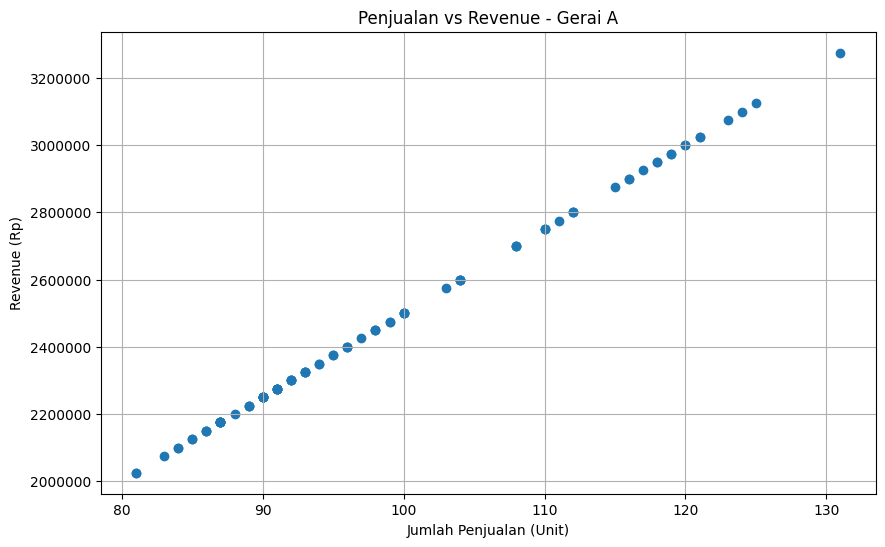

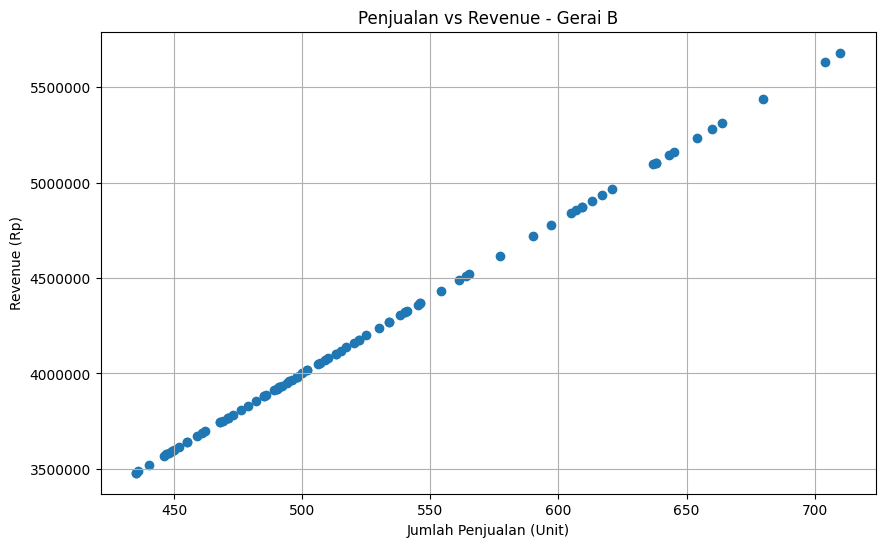

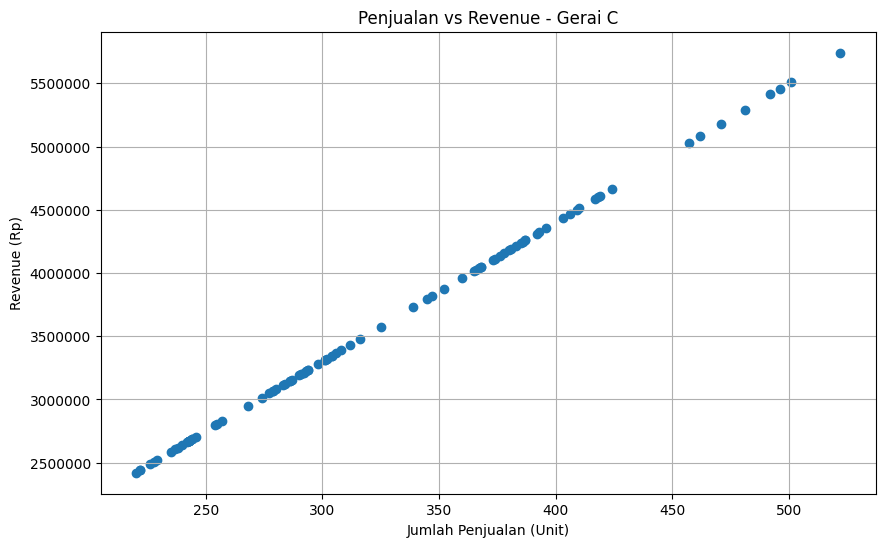

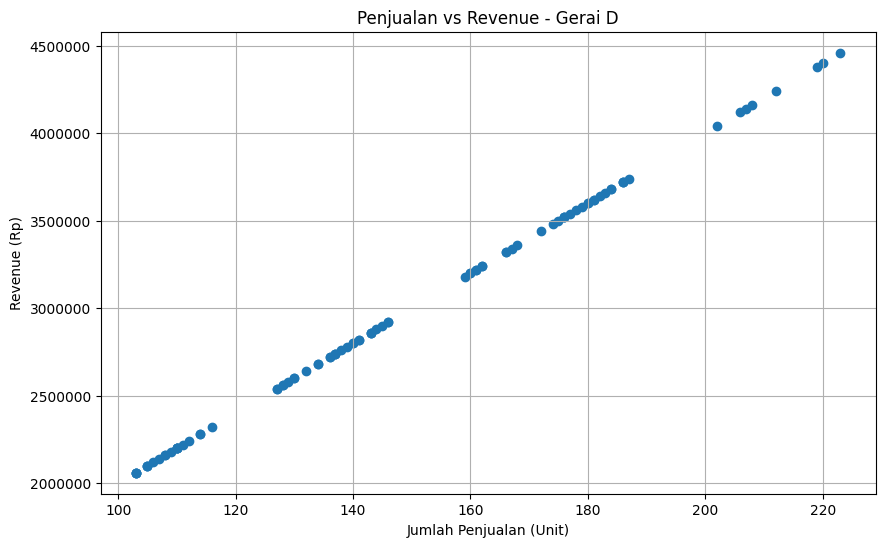

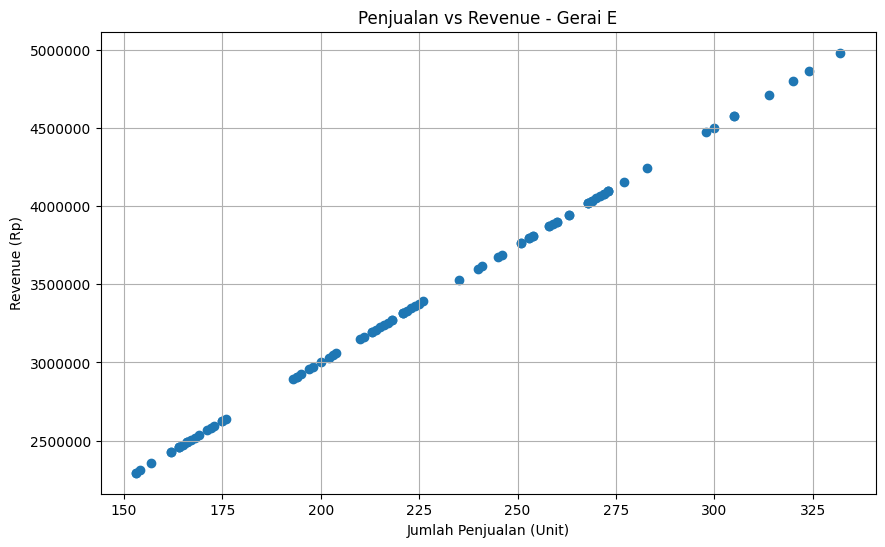

In [29]:
for gerai in df["Gerai"].unique():
    plt.figure(figsize=(10, 6))
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"]
    )

    plt.title("Penjualan vs Revenue - " + gerai)
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")

    plt.ticklabel_format(style='plain', axis='y')

    plt.grid(True)
    plt.show()

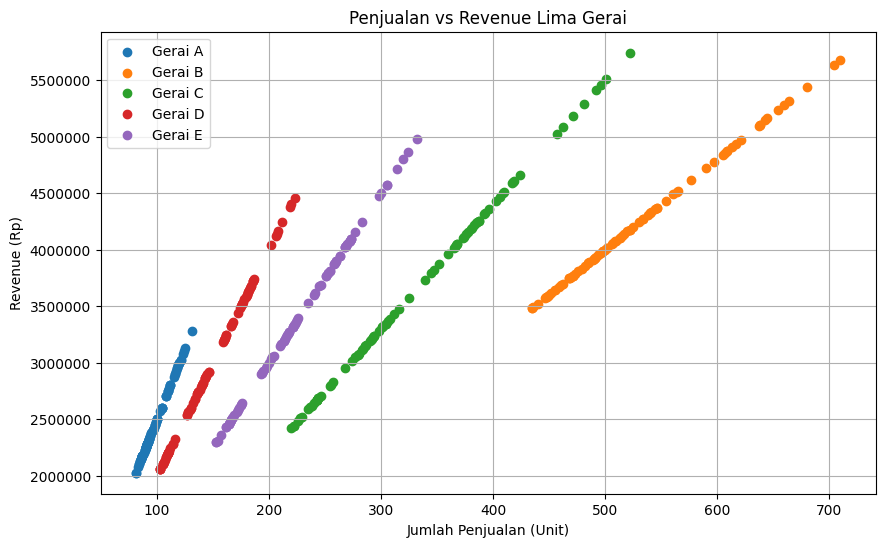

In [26]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai
    )

plt.title("Penjualan vs Revenue Lima Gerai")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.grid(True)
plt.show()

### Interpretasi visual

Berdasarkan grafik, terlihat bahwa revenue meningkat ketika jumlah donat yang terjual meningkat pada seluruh gerai. Pola masing-masing gerai membentuk garis yang hampir atau tepat linear. Hal ini terjadi karena harga jual pada masing-masing gerai relatif tetap. Dengan demikian, revenue dapat dinyatakan sebagai:

**Revenue = Harga Jual × Jumlah Terjual**

Perbedaan posisi garis antar-gerai menunjukkan perbedaan harga jual. Gerai dengan harga jual lebih tinggi menghasilkan revenue yang lebih besar pada volume penjualan yang sama.


## Regresi Revenue terhadap Jumlah Penjualan

In [16]:
hasil_regresi = {}

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(X, y)

    hasil_regresi[gerai] = {
        "model": model,
        "slope": slope,
        "intercept": intercept,
        "R2": r2
    }

    print(f"\n{gerai}")
    print(f"Persamaan: Revenue = {slope:.2f} × Penjualan + {intercept:.2f}")
    print(f"R² = {r2:.4f}")


Gerai A
Persamaan: Revenue = 25000.00 × Penjualan + -0.00
R² = 1.0000

Gerai B
Persamaan: Revenue = 8000.00 × Penjualan + 0.00
R² = 1.0000

Gerai C
Persamaan: Revenue = 11000.00 × Penjualan + 0.00
R² = 1.0000

Gerai D
Persamaan: Revenue = 20000.00 × Penjualan + -0.00
R² = 1.0000

Gerai E
Persamaan: Revenue = 15000.00 × Penjualan + -0.00
R² = 1.0000


### Interpretasi hasil regresi

Nilai R² sebesar 1,0000, ini menunjukkan bahwa model linear menjelaskan seluruh variasi revenue berdasarkan jumlah penjualan pada dataset ini.

Hasil tersebut masuk akal karena revenue dihitung berdasarkan harga jual dikalikan jumlah produk yang terjual. Jadi, hubungan kedua variabel memang bersifat linear.

Koefisien regresi juga menunjukkan harga jual masing-masing gerai. Misalnya:

- Gerai A: setiap tambahan 1 donat meningkatkan revenue sekitar Rp25.000
- Gerai B: setiap tambahan 1 donat meningkatkan revenue sekitar Rp8.000
- Gerai C: setiap tambahan 1 donat meningkatkan revenue sekitar Rp11.000
- Gerai D: setiap tambahan 1 donat meningkatkan revenue sekitar Rp20.000
- Gerai E: setiap tambahan 1 donat meningkatkan revenue sekitar Rp15.000


## Visualisasi Garis Regresi

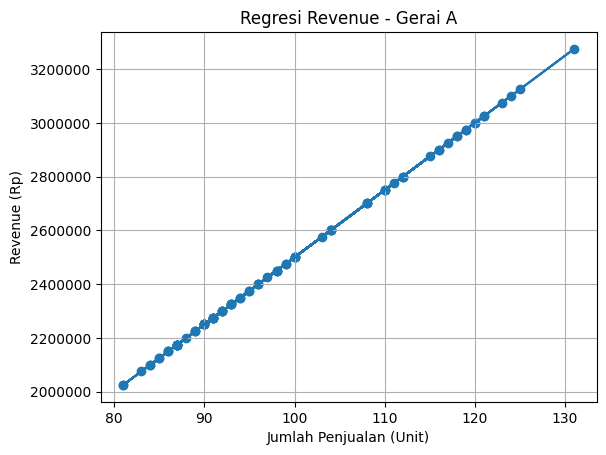

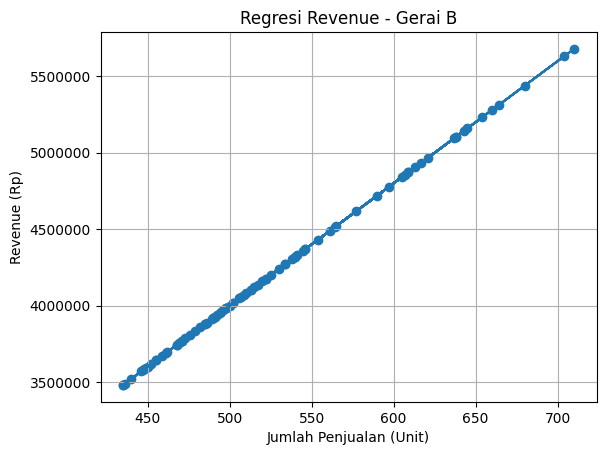

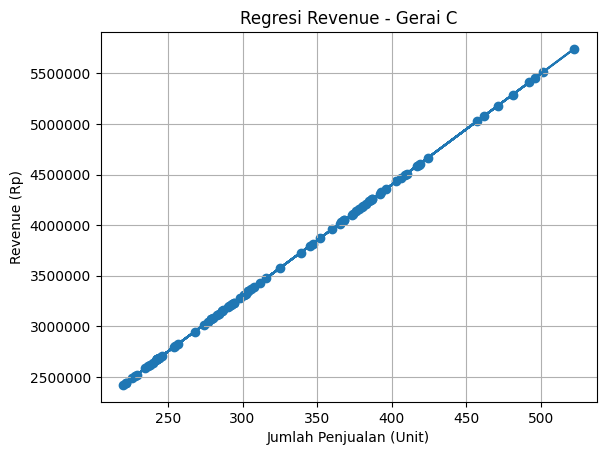

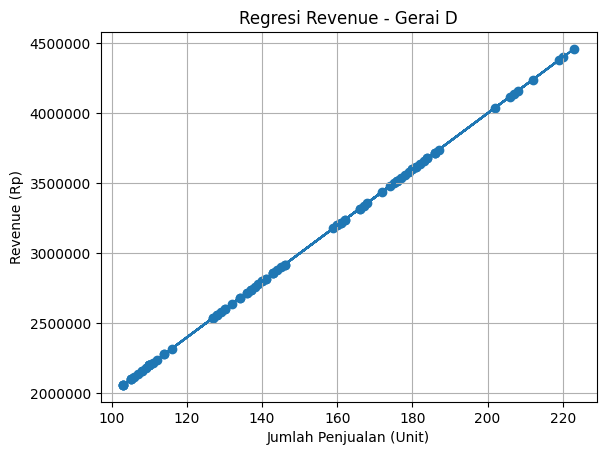

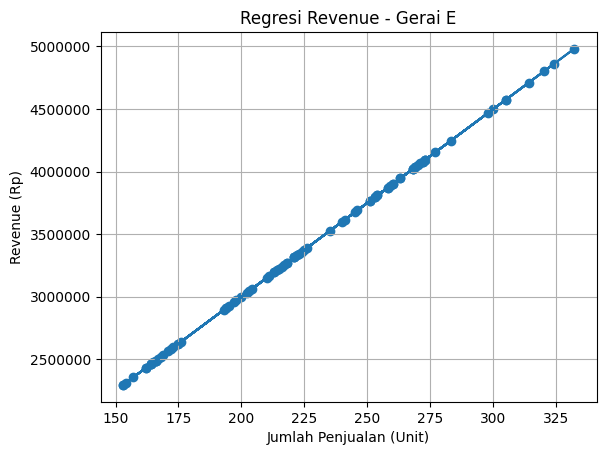

In [30]:
for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    plt.scatter(X, y)
    plt.plot(X, model.predict(X))

    plt.title("Regresi Revenue - " + gerai)
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")

    plt.ticklabel_format(style='plain', axis='y')

    plt.grid(True)
    plt.show()

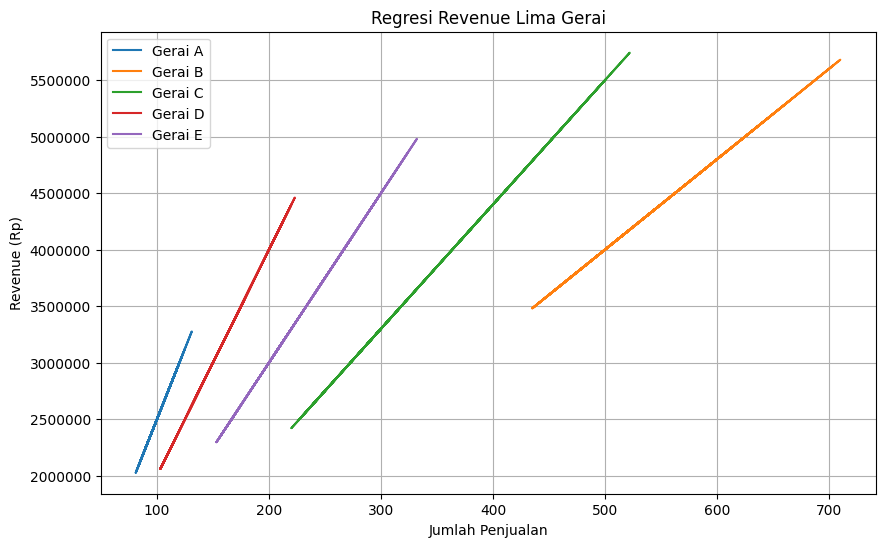

In [33]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    plt.plot(
        X,
        model.predict(X),
        label=gerai
    )

plt.title("Regresi Revenue Lima Gerai")
plt.xlabel("Jumlah Penjualan")
plt.ylabel("Revenue (Rp)")
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True)
plt.show()

### Interpretasi

Garis regresi menunjukkan tren peningkatan revenue seiring dengan bertambahnya jumlah produk yang terjual. Semua gerai memiliki pola linear.

Kemiringan garis berbeda karena setiap gerai menggunakan harga jual yang berbeda. Gerai dengan harga jual lebih tinggi mempunyai kemiringan garis yang lebih besar.


## Regresi Balance untuk mencari Break Even Point

In [18]:
hasil_bep = {}

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    # Mencari akar persamaan balance = 0
    bep = -b / a

    r2 = model.score(X, y)

    hasil_bep[gerai] = {
        "slope": a,
        "intercept": b,
        "BEP": bep,
        "R2": r2
    }

    print(f"\n{gerai}")
    print(f"Persamaan Balance = {a:.2f} × Penjualan + {b:.2f}")
    print(f"BEP = {bep:.2f} unit")
    print(f"R² = {r2:.4f}")


Gerai A
Persamaan Balance = 16500.00 × Penjualan + -1683333.00
BEP = 102.02 unit
R² = 1.0000

Gerai B
Persamaan Balance = 3840.00 × Penjualan + -733333.00
BEP = 190.97 unit
R² = 1.0000

Gerai C
Persamaan Balance = 6160.00 × Penjualan + -1733333.00
BEP = 281.39 unit
R² = 1.0000

Gerai D
Persamaan Balance = 12800.00 × Penjualan + -2666666.00
BEP = 208.33 unit
R² = 1.0000

Gerai E
Persamaan Balance = 8700.00 × Penjualan + -800000.00
BEP = 91.95 unit
R² = 1.0000


BEP terjadi ketika:

**Laba/Rugi = 0**

Jika hasil regresi balance berbentuk:

**Balance = aX + b**

maka akar persamaan diperoleh dari:

**X = -b/a**

Nilai X tersebut merupakan volume penjualan ketika gerai mencapai kondisi impas.


### Hasil BEP

Berdasarkan dataset, hasil regresi menghasilkan volume BEP sekitar:

| Gerai | Volume BEP |
|---|---:|
| A | 102 unit/hari |
| B | 191 unit/hari |
| C | 281 unit/hari |
| D | 208 unit/hari |
| E | 92 unit/hari |

Karena jumlah donat merupakan bilangan bulat, volume operasional dapat dibulatkan ke atas.


## Visualisasi BEP

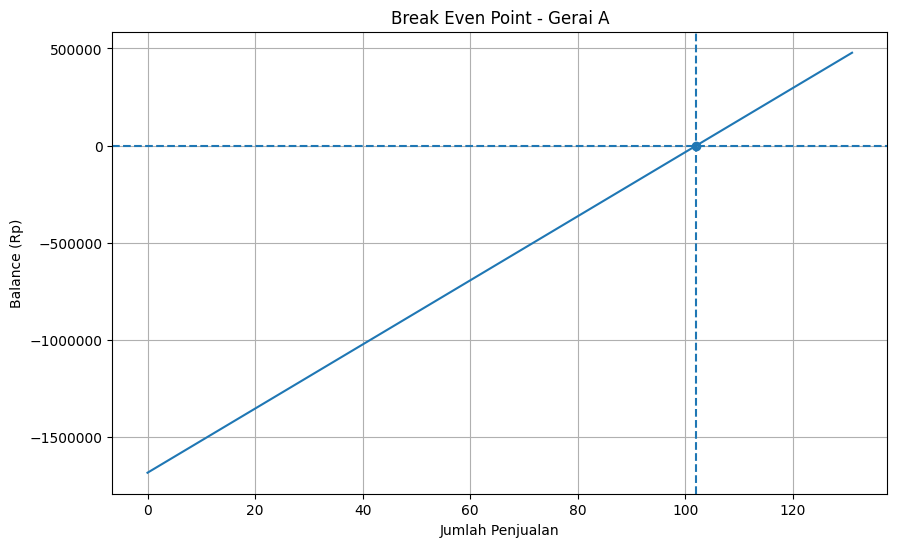

Gerai A BEP = 102.02 unit


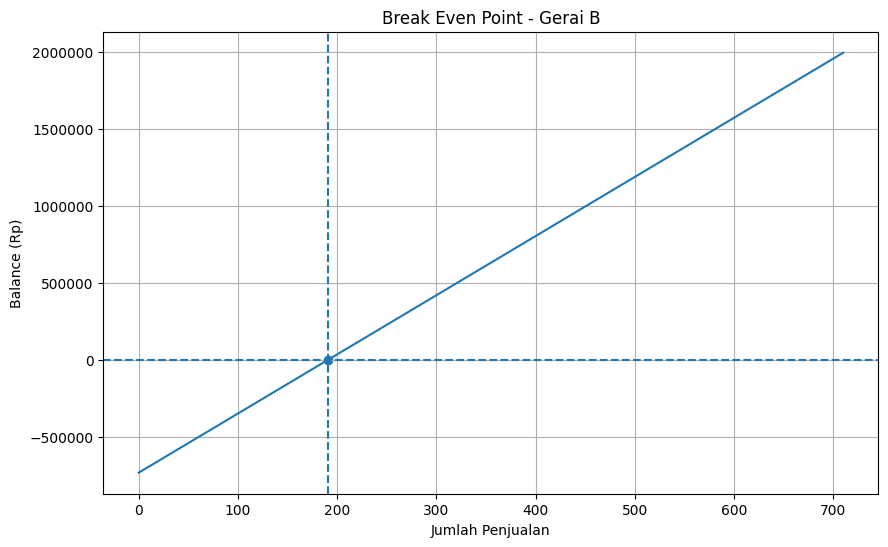

Gerai B BEP = 190.97 unit


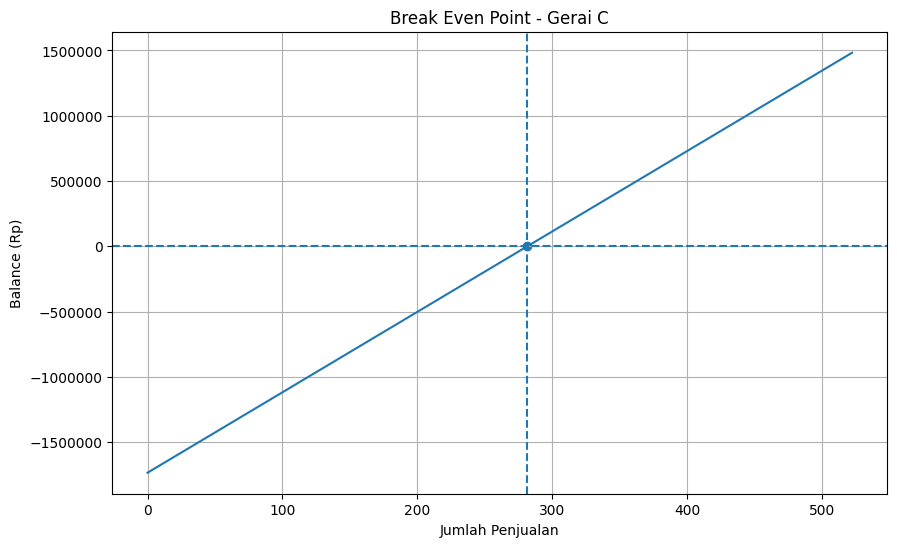

Gerai C BEP = 281.39 unit


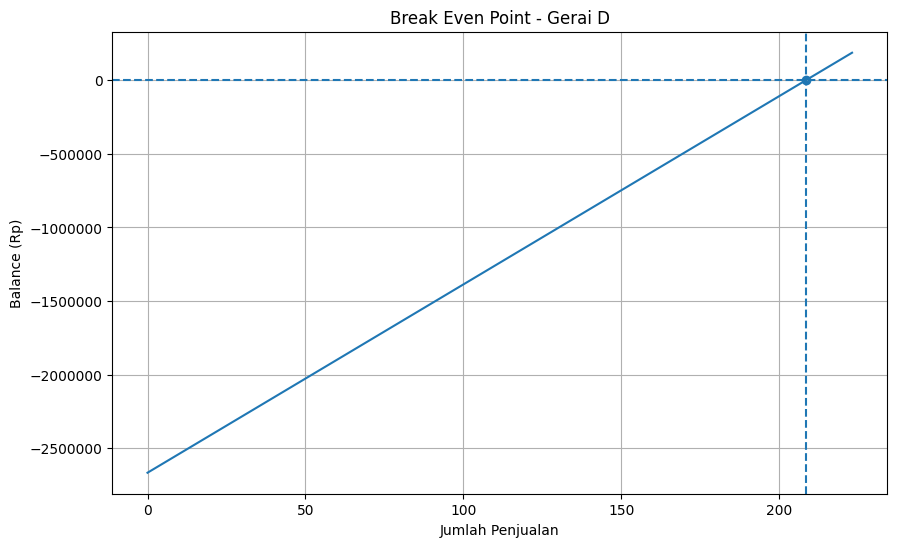

Gerai D BEP = 208.33 unit


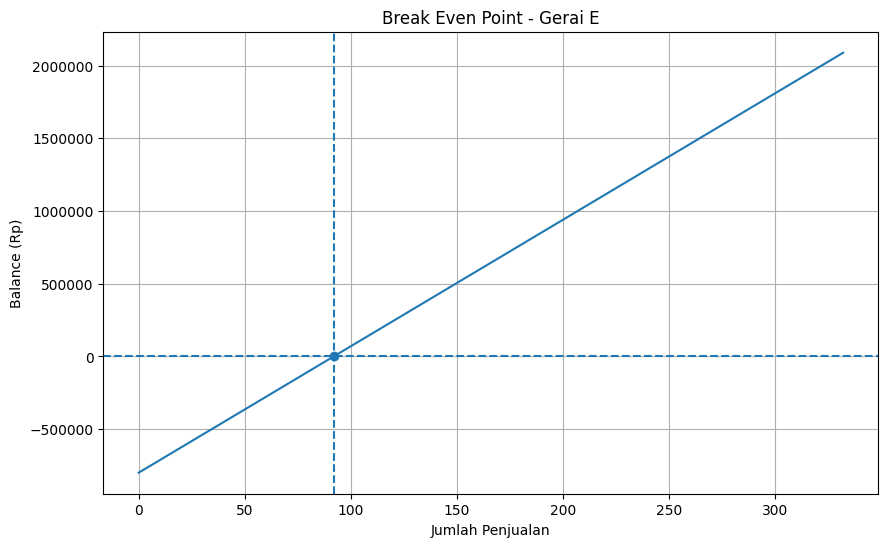

Gerai E BEP = 91.95 unit


In [35]:
for gerai in df["Gerai"].unique():

    plt.figure(figsize=(10, 6))
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    bep = -b / a

    x = np.linspace(
        0,
        data["Jumlah Terjual (Unit)"].max(),
        100
    )

    plt.plot(x, a*x + b)
    plt.axhline(0, linestyle="--")
    plt.axvline(bep, linestyle="--")
    plt.scatter(bep, 0)

    plt.title("Break Even Point - " + gerai)
    plt.xlabel("Jumlah Penjualan")
    plt.ylabel("Balance (Rp)")
    plt.ticklabel_format(style='plain', axis='y')

    plt.grid(True)
    plt.show()

    print(gerai, "BEP =", round(bep, 2), "unit")

### Interpretasi

Garis horizontal pada Rp0 merupakan kondisi break even point. Titik perpotongan antara garis regresi masing-masing gerai dengan garis Rp0 menunjukkan jumlah penjualan yang diperlukan agar gerai mencapai kondisi impas.

Dari hasil regresi:

- Gerai A mencapai BEP pada sekitar 102 unit
- Gerai B mencapai BEP pada sekitar 191 unit
- Gerai C mencapai BEP pada sekitar 281 unit
- Gerai D mencapai BEP pada sekitar 208 unit
- Gerai E mencapai BEP pada sekitar 92 unit

Jika volume penjualan berada di bawah titik tersebut, model memprediksi balance negatif. Jika volume penjualan melewati titik tersebut, model memprediksi balance positif.


## Kesimpulan

Hasil analisis menunjukkan bahwa hubungan antara jumlah penjualan dan revenue pada kelima gerai berbentuk linear. Nilai R² sebesar 1 menunjukkan bahwa jumlah penjualan menjelaskan seluruh variasi revenue pada dataset. Perbedaan kemiringan garis regresi disebabkan oleh perbedaan harga jual pada masing-masing gerai.

Untuk menentukan break even point, digunakan regresi antara jumlah penjualan dan balance. Akar dari persamaan regresi tersebut diperoleh dengan menetapkan balance sama dengan nol. Hasilnya menunjukkan bahwa volume penjualan BEP Gerai A sekitar 102 unit, Gerai B sekitar 191 unit, Gerai C sekitar 281 unit, Gerai D sekitar 208 unit, dan Gerai E sekitar 92 unit per hari. Nilai tersebut menunjukkan volume penjualan yang diperlukan agar pendapatan menutup biaya yang tercatat dalam dataset.
